In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,StandardScaler,OneHotEncoder

In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE,ADASYN

In [6]:
# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


#Evaluation metrics
from sklearn.metrics import accuracy_score,roc_auc_score,f1_score,precision_score,recall_score,r2_score,mean_absolute_error
from sklearn.metrics import confusion_matrix,classification_report

In [7]:
#The dataset was loaded into a Pandas DataFrame for analysis and preprocessing.

parkinson_df=pd.read_csv(r'E:\DS\PROJECTS\MULTIPLE_DISEASE_PREDICTION\MULTIPLE_DISEASE_PREDICTION\parkinsons - parkinsons.csv')
parkinson_df

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [8]:
parkinson_df.shape

(195, 24)

In [9]:
parkinson_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [10]:
parkinson_df.describe(include='all')

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
unique,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,phon_R01_S01_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,NaN,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,NaN,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,NaN,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,NaN,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,NaN,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980


In [11]:
parkinson_df['status'].value_counts(normalize=True)


status
1    0.753846
0    0.246154
Name: proportion, dtype: float64

In [12]:
parkinson_df.isnull().sum()

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [13]:
parkinson_df.duplicated().sum()

#Performed initial data inspection to understand data types, distribution, and missing values.
#No missing values were found in the dataset.

np.int64(0)

In [14]:
parkinson_df=parkinson_df.drop('name',axis=1)

#The name column was removed as it represents a unique identifier and does not contribute meaningful information for prediction

In [15]:
parkinson_df.skew()

MDVP:Fo(Hz)         0.591737
MDVP:Fhi(Hz)        2.542146
MDVP:Flo(Hz)        1.217350
MDVP:Jitter(%)      3.084946
MDVP:Jitter(Abs)    2.649071
MDVP:RAP            3.360708
MDVP:PPQ            3.073892
Jitter:DDP          3.362058
MDVP:Shimmer        1.666480
MDVP:Shimmer(dB)    1.999389
Shimmer:APQ3        1.580576
Shimmer:APQ5        1.798697
MDVP:APQ            2.618047
Shimmer:DDA         1.580618
NHR                 4.220709
HNR                -0.514317
status             -1.187727
RPDE               -0.143402
DFA                -0.033214
spread1             0.432139
spread2             0.144430
D2                  0.430384
PPE                 0.797491
dtype: float64

In [16]:
(parkinson_df==0).sum()

MDVP:Fo(Hz)          0
MDVP:Fhi(Hz)         0
MDVP:Flo(Hz)         0
MDVP:Jitter(%)       0
MDVP:Jitter(Abs)     0
MDVP:RAP             0
MDVP:PPQ             0
Jitter:DDP           0
MDVP:Shimmer         0
MDVP:Shimmer(dB)     0
Shimmer:APQ3         0
Shimmer:APQ5         0
MDVP:APQ             0
Shimmer:DDA          0
NHR                  0
HNR                  0
status              48
RPDE                 0
DFA                  0
spread1              0
spread2              0
D2                   0
PPE                  0
dtype: int64

In [17]:
skewed_cols=parkinson_df.drop('status',axis=1).skew()
skewed_cols=skewed_cols[abs(skewed_cols)>1].index

for col in skewed_cols:
    parkinson_df[col]=np.log1p(parkinson_df[col])
    

In [18]:
parkinson_df[skewed_cols].skew()

MDVP:Fhi(Hz)        1.097633
MDVP:Flo(Hz)        0.665075
MDVP:Jitter(%)      3.053912
MDVP:Jitter(Abs)    2.648775
MDVP:RAP            3.339918
MDVP:PPQ            3.056097
Jitter:DDP          3.301064
MDVP:Shimmer        1.603423
MDVP:Shimmer(dB)    1.498652
Shimmer:APQ3        1.548673
Shimmer:APQ5        1.754727
MDVP:APQ            2.476712
Shimmer:DDA         1.491119
NHR                 3.916116
dtype: float64

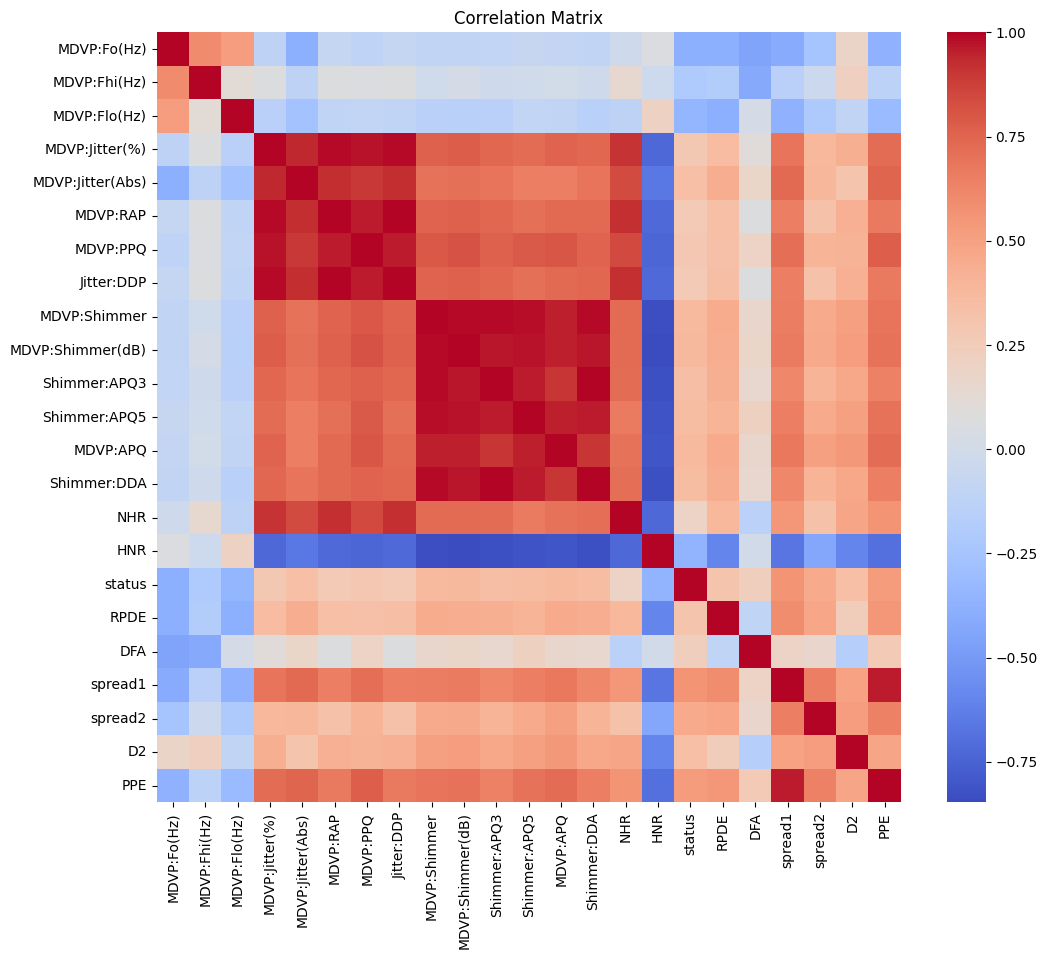

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(parkinson_df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Correlation between features

In [20]:
X = parkinson_df.drop('status', axis=1)
y = parkinson_df['status']

#Separated independent features and target variable.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

X_train.shape, X_test.shape

((156, 22), (39, 22))

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Standardized features to improve performance of Logistic Regression.

In [23]:
#Logistic Regression

LG= LogisticRegression(max_iter=100)

LG.fit(X_train_scaled, y_train)
y_pred_LG = LG.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_LG))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_LG))
print("\nClassification Report:\n", classification_report(y_test, y_pred_LG))

Accuracy: 0.9230769230769231

Confusion Matrix:
 [[ 8  2]
 [ 1 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



In [24]:
#Random Forest

RF=RandomForestClassifier()
RF.fit(X_train,y_train)

y_pred_RF=RF.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_RF))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_RF))
print("\nClassification Report:\n", classification_report(y_test, y_pred_RF))

Accuracy: 0.9487179487179487

Confusion Matrix:
 [[ 9  1]
 [ 1 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39



In [25]:
#XG BOOSTER

XGB=XGBClassifier()
XGB.fit(X_train,y_train)

y_pred_XGB=XGB.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_XGB))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred_XGB))
print("\nClassification Report:\n", classification_report(y_test,y_pred_XGB))

Accuracy: 0.9230769230769231

Confusion Matrix:
 [[ 8  2]
 [ 1 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



##### Model	Accuracy
Logistic Regression - 0.92,
Random Forest - 0.92,
XGBoost - 0.95 (Best)

Random Forest performed best before tuning.

In [26]:
from sklearn.model_selection import GridSearchCV

In [27]:
# Hyperparameter Tuning

parameters={'n_estimators':[50,100,200],
           'max_depth':[None,5,10,20],
           'min_samples_split':[2,5,10],
           'min_samples_leaf':[1,2,4]}

In [28]:
grid=GridSearchCV(
    estimator=RF,
    param_grid=parameters,
    cv=3)

In [29]:
grid.fit(X_train,y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.9038461538461539


In [30]:
best_RF= grid.best_estimator_

In [31]:
y_pred_best = best_RF.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred_best))
print("\nClassification Report:\n", classification_report(y_test,y_pred_best))

Accuracy: 0.9487179487179487

Confusion Matrix:
 [[ 9  1]
 [ 1 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39



##### Test accuracy : 0.89 and Test accuracy : 0.89 after tuning

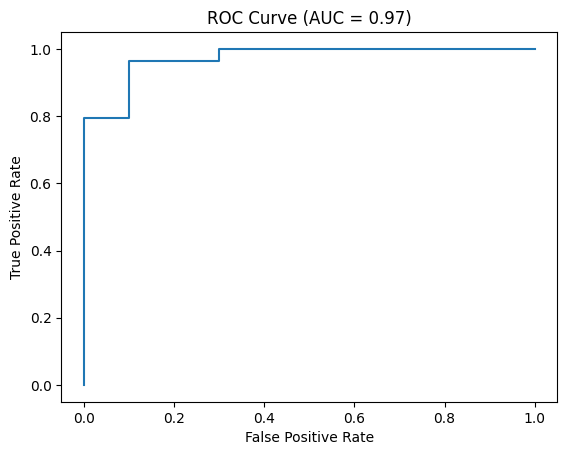

In [32]:
from sklearn.metrics import roc_curve, auc

y_prob = RF.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()


In [33]:
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9724137931034482


##### ROC-AUC Score
The model can separate Parkinson and Healthy patients very well.
AUC close to 1 indicates strong performance.

##### Conclusion                                                                                                    

In this project, machine learning models were used to predict Parkinson’s disease using voice measurements.    Random Forest achieved the highest accuracy and ROC-AUC score.                                                     The final model was saved for deployment in a Streamlit web application.


In [34]:
import pickle

with open("parkinson_model.pkl", "wb") as file:
   pickle.dump(RF, file)

In [35]:
with open("parkinson_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [36]:
feature_columns_parkinson = X.columns.tolist()

In [37]:
pickle.dump(feature_columns_parkinson, open("parkinson_features.pkl", "wb"))